# Lotka Volterra

The model {func}`.Lotka_Volterra` is a basic predator and prey model {cite}`Lotka1920`.
This is more commonly expressed in terms of predator and prey population area densities, $x$ and $y$ respectively, though we define the model in terms of absolute numbers, $X$ and $Y$, in a given area, $A$.
This decision to define in terms of population numbers, rather than densities, permits us to perform stochastic simulations.

$$\begin{aligned}
\frac{\mathrm{d} X}{\mathrm{d} t} &= \alpha X - \frac{\beta X Y}{A}  \\
\frac{\mathrm{d} Y}{\mathrm{d} t} &= -\gamma Y + \frac{\delta X Y}{A}
\end{aligned}$$

We first solve this model for the deterministic case:

In [1]:
from pygom import common_models
import numpy as np
import matplotlib.pyplot as plt
import math

# Initial populations
x0 = [40, 20]

# Parameters from a snowshoe hare / Canadian lynx system
# https://mc-stan.org/users/documentation/case-studies/lotka-volterra-predator-prey.html
alpha = 0.545
beta = 0.028
gamma = 0.803
delta = 0.024

# scale up the population (this will need scaling in the predation parameters)
scale = 10

x0 = [x * scale for x in x0]
beta = beta/scale
delta = delta/scale


model = common_models.Lotka_Volterra(
    {
        'alpha': alpha,
        'beta':beta,
        'gamma':gamma,
        'delta':delta
    }
)

tmax = 50                               # maximum time over which to run solver
dt = 0.1                                # timestep
t = np.arange(0, tmax, dt)

model.initial_values = (x0, t[0])

solution = model.solve_deterministic(t)

We see that the predator and prey populations show periodic behaviour with a phase shift between them.

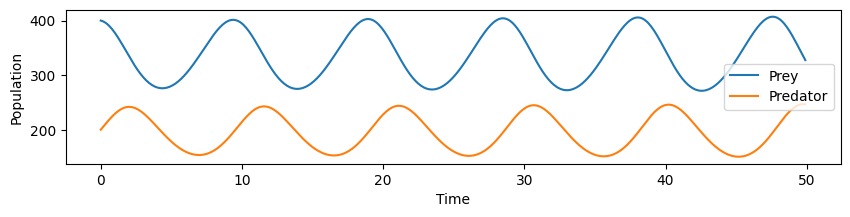

In [4]:
fig, axes = plt.subplots(figsize=(10, 2))

state_names = ["Prey", "Predator"]

for i in range(len(state_names)):
    axes.plot(t, solution[0].result.y[:, i], label=state_names[i])
axes.set_xlabel("Time")
axes.set_ylabel("Population")
axes.legend()
plt.show()

We can also see how the system evolves stochastically

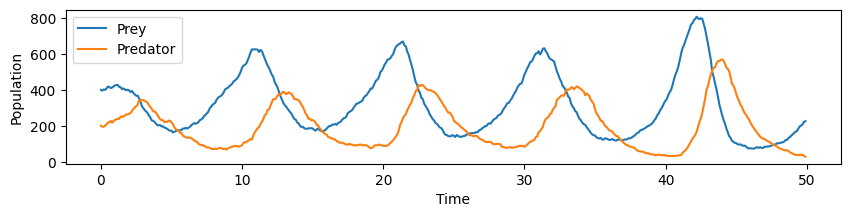

In [ ]:
n_sim = 1
solution = model.solve_stochastic(
    t=t,
    method="fixed_tau",
    tau=0.01,
    iteration=n_sim,
    seed=1
)

fig, ax = plt.subplots(figsize=(10, 2))

for i, name in enumerate(state_names):
    ax.plot(t, solution[0].result.y[:, i], label=name)

ax.set(
    xlabel="Time",
    ylabel="Population",
)

ax.legend()
plt.tight_layout()
plt.show()

This appears to be unstable, since the populations undergo increasingly extreme peaks and troughs.
This can be confirmed by examining a phase diagram, whereby the trajectory in state space spirals outwards.

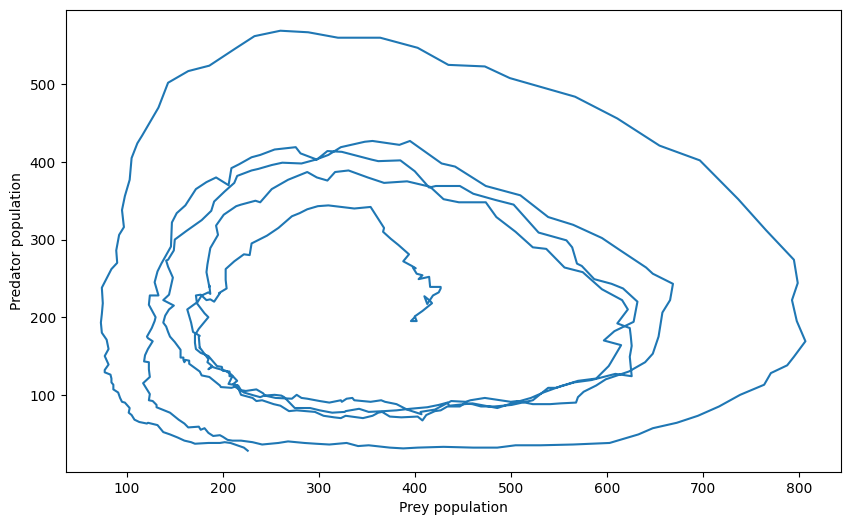

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    solution[0].result.y[:, 0],
    solution[0].result.y[:, 1]
)

ax.set(
    xlabel="Prey population",
    ylabel="Predator population",
)

plt.tight_layout()
plt.show()